# 07 · Test-set Evaluation, SHAP, Equity

Evaluate best models on the TEST split (Ida 2021 + Ian 2022 — NEVER seen during training or tuning). Compute SHAP, produce equity audit by SVI quartile.

In [6]:
import sys, os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 60)
from config import (
    DATA_PATHS, HURRICANE_META, STATES_IN_SCOPE,
    TARGET_COL, TARGET_CLASS_COL, FEATURE_GROUPS,
    RANDOM_STATE, SEVERITY_BINS, SEVERITY_LABELS,
)
RAW = DATA_PATHS['raw']; INTERIM = DATA_PATHS['interim']
PROC = DATA_PATHS['processed']; MODELS = DATA_PATHS['models']
OUT = DATA_PATHS['outputs']


In [7]:
import joblib, shap
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from src.evaluation import equity_audit, svi_quartile, shap_mean_abs_by_group
pkg = joblib.load(MODELS / 'best_classifier.pkl')
pipe, le, features = pkg['pipe'], pkg['label_encoder'], pkg['features']
df = pd.read_csv(PROC / 'abt_with_clusters.csv', dtype={'zip_code': str}).dropna(subset=[TARGET_CLASS_COL])
te = df[df['train_test_split']=='TEST'].copy()
Xte = te[features]; yte = le.transform(te[TARGET_CLASS_COL])

## Classification metrics

c:\Users\chaitanya\Documents\ML Project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\chaitanya\Documents\ML Project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


              precision    recall  f1-score   support

        High       0.06      0.07      0.06    120324
         Low       0.76      0.58      0.65   1017815
      Medium       0.07      0.14      0.09    113013
      Severe       0.10      0.17      0.13    121201

    accuracy                           0.46   1372353
   macro avg       0.25      0.24      0.23   1372353
weighted avg       0.58      0.46      0.51   1372353



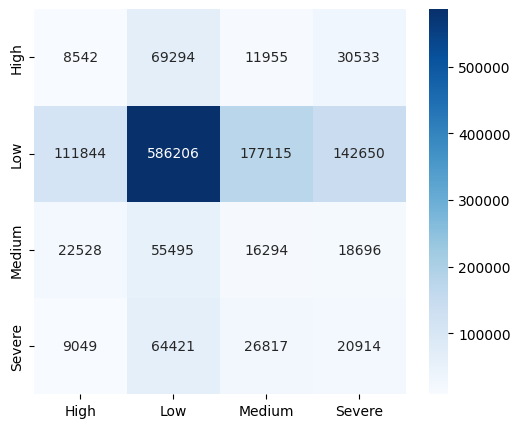

macro ROC-AUC: 0.48333611167532275


In [8]:
pred = pipe.predict(Xte); proba = pipe.predict_proba(Xte)
print(classification_report(yte, pred, target_names=le.classes_, zero_division=0))
cm = confusion_matrix(yte, pred)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.savefig(OUT / 'test_confusion.png', dpi=150); plt.show()
# ROC AUC one-vs-rest
print('macro ROC-AUC:', roc_auc_score(pd.get_dummies(yte), proba, multi_class='ovr'))

## Regression metrics (per-hurricane)

In [9]:
pkgR = joblib.load(MODELS / 'best_regressor.pkl')
yhat = pkgR['pipe'].predict(Xte)
te['yhat'] = yhat
for hn, sub in te.groupby('hurricane_name'):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = np.sqrt(mean_squared_error(sub[TARGET_COL], sub['yhat']))
    mae = mean_absolute_error(sub[TARGET_COL], sub['yhat'])
    r2 = r2_score(sub[TARGET_COL], sub['yhat'])
    print(f'{hn}: RMSE={rmse:.2f} MAE={mae:.2f} R2={r2:.3f}')

c:\Users\chaitanya\Documents\ML Project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Ian: RMSE=28.90 MAE=20.86 R2=-0.689
Ida: RMSE=42.76 MAE=33.67 R2=-0.038


## SHAP — tree explainer on preprocessed matrix

In [10]:
# Extract preprocessor + model
pre = pipe.named_steps['pre']; model = pipe.named_steps['model']
Xte_t = pre.transform(Xte)
if hasattr(Xte_t, 'toarray'): Xte_t = Xte_t.toarray()  # SHAP needs dense
try: feat_names = pre.get_feature_names_out()
except Exception: feat_names = [f'f{i}' for i in range(Xte_t.shape[1])]

# TreeExplainer only handles tree-based models (RF/XGB/LGBM/GBM).
# For NB / SVM / LR fall back to KernelExplainer on a sampled subset.
from sklearn.ensemble._forest import BaseForest
mtype = type(model).__name__
is_tree = (isinstance(model, BaseForest)
           or 'XGB' in mtype or 'LGB' in mtype or 'GradientBoosting' in mtype)

if is_tree:
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(Xte_t)
else:
    rng = np.random.RandomState(RANDOM_STATE)
    n_sample = min(500, len(Xte_t))
    sample_idx = np.sort(rng.choice(len(Xte_t), size=n_sample, replace=False))
    bg = shap.sample(Xte_t, 100, random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(model.predict_proba, bg)
    sv = explainer.shap_values(Xte_t[sample_idx])
    # Subset all aligned arrays so downstream cells stay consistent
    Xte_t = Xte_t[sample_idx]
    te = te.iloc[sample_idx].reset_index(drop=True)
    Xte = Xte.iloc[sample_idx].reset_index(drop=True)
    pred = pred[sample_idx]; proba = proba[sample_idx]; yte = yte[sample_idx]
    print(f'KernelExplainer on stratified sample of {n_sample} test rows')

# Normalize SHAP output to (n_samples, n_features, n_classes)
if isinstance(sv, list):
    sv_arr = np.stack(sv, axis=-1)
elif np.asarray(sv).ndim == 2:
    sv_arr = np.asarray(sv)[..., np.newaxis]
else:
    sv_arr = np.asarray(sv)
print('sv shape', sv_arr.shape)
severe_idx = list(le.classes_).index('Severe')
np.save(OUT / 'shap_values.npy', sv_arr)

c:\Users\chaitanya\Documents\ML Project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
100%|██████████| 500/500 [02:19<00:00,  3.59it/s]

KernelExplainer on stratified sample of 500 test rows
sv shape (500, 29, 4)


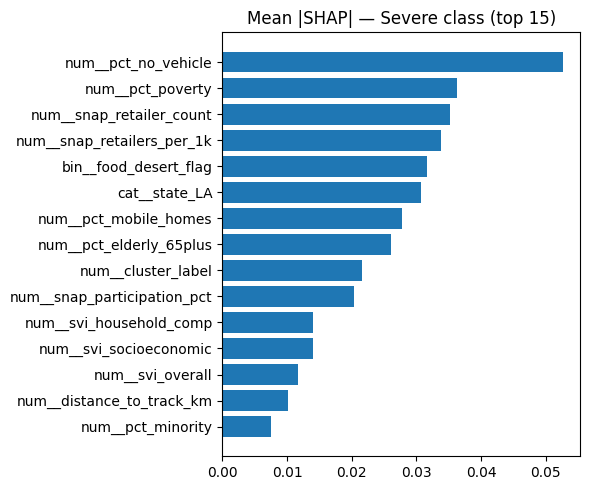

In [11]:
shap.summary_plot(sv_arr[:,:,severe_idx], Xte_t, feature_names=feat_names, show=False, max_display=15)
plt.savefig(OUT / 'shap_beeswarm_severe.png', dpi=150, bbox_inches='tight'); plt.close()
# global bar
mabs = np.mean(np.abs(sv_arr[:,:,severe_idx]), axis=0)
order = np.argsort(mabs)[-15:]
fig, ax = plt.subplots(figsize=(6,5))
ax.barh(np.array(feat_names)[order], mabs[order])
ax.set_title('Mean |SHAP| — Severe class (top 15)')
plt.tight_layout(); plt.savefig(OUT / 'shap_global_severe.png', dpi=150); plt.show()

In [12]:
# Waterfall for 3 zips (Low, High, Severe predictions)
for cls in ['Low', 'High', 'Severe']:
    idxs = np.where(pred == list(le.classes_).index(cls))[0]
    if len(idxs)==0: continue
    i = idxs[0]
    shap.plots.waterfall(shap.Explanation(
        values=sv_arr[i,:,severe_idx],
        base_values=explainer.expected_value[severe_idx] if isinstance(explainer.expected_value, (list,np.ndarray)) else explainer.expected_value,
        data=Xte_t[i], feature_names=feat_names), show=False)
    plt.savefig(OUT / f'shap_waterfall_{cls}.png', dpi=150, bbox_inches='tight'); plt.close()

## Equity audit — recall for Severe by SVI quartile

In [13]:
te_valid = te.dropna(subset=['svi_overall']).copy()
te_valid['svi_q'] = svi_quartile(te_valid['svi_overall'])
pred_lbl = le.inverse_transform(pred[te.index.isin(te_valid.index)])
audit = equity_audit(te_valid[TARGET_CLASS_COL].reset_index(drop=True),
                     pd.Series(pred_lbl), te_valid['svi_q'].reset_index(drop=True))
audit.to_csv(OUT / 'equity_audit.csv')
audit

,accuracy,f1_weighted,recall_severe,dp_ratio,eo_diff
svi_q,,,,,
Q1 (Low),0.187970,0.225794,0.000000,0.0,0.628866
Q2,0.632479,0.666491,0.000000,0.0,0.628866
Q3,0.604167,0.580335,0.125000,0.0,0.628866
Q4 (High),0.292453,0.342905,0.444444,0.0,0.628866
__overall__,0.434000,0.493157,0.138889,0.0,0.628866


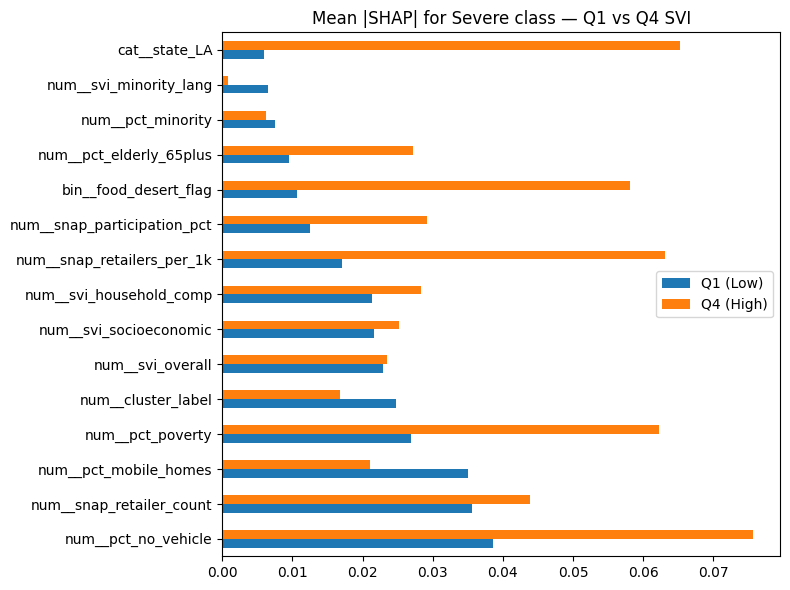

In [14]:
# SHAP stratified by SVI quartile
grp_align = te_valid['svi_q'].reset_index(drop=True)
idx_align = te.reset_index(drop=True).index.isin(te_valid.reset_index().index)
sv_class = sv_arr[idx_align, :, severe_idx]
by_grp = shap_mean_abs_by_group(sv_class, feat_names, grp_align)
by_grp[['Q1 (Low)','Q4 (High)']].head(15).plot(kind='barh', figsize=(8,6))
plt.title('Mean |SHAP| for Severe class — Q1 vs Q4 SVI')
plt.tight_layout(); plt.savefig(OUT / 'shap_by_svi.png', dpi=150); plt.show()